In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications import ConvNeXtLarge
from tensorflow.keras import layers, Model
import tensorflow_hub as hub
import kagglehub

In [3]:
path = kagglehub.dataset_download("serenaraju/yawn-eye-dataset-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'yawn-eye-dataset-new' dataset.
Path to dataset files: /kaggle/input/yawn-eye-dataset-new


In [4]:
path = "/kaggle/input/yawn-eye-dataset-new"

for item in os.listdir(path):
    print(item)

dataset_new


In [5]:
BASE = "/kaggle/input/yawn-eye-dataset-new/dataset_new"

train_dir = os.path.join(BASE, "train")
test_dir  = os.path.join(BASE, "test")

print(train_dir)
print(test_dir)

CLASSES = sorted(os.listdir(train_dir))
NUM_CLASSES = len(CLASSES)
print("Classes:", CLASSES)

/kaggle/input/yawn-eye-dataset-new/dataset_new/train
/kaggle/input/yawn-eye-dataset-new/dataset_new/test
Classes: ['Closed', 'Open', 'no_yawn', 'yawn']


In [6]:
IMAGE_SIZE = 256

def carregar_dataset_np(root):
    imagens = []
    rotulos = []

    for label, cls in enumerate(CLASSES):
        cls_path = os.path.join(root, cls)

        for fname in os.listdir(cls_path):
            if fname.lower().endswith(("jpg","png","jpeg")):
                img_path = os.path.join(cls_path, fname)

                img = Image.open(img_path).convert("RGB")
                img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

                img = np.array(img, dtype=np.float32) / 255.0

                imagens.append(img)
                rotulos.append(label)

    return np.array(imagens), np.array(rotulos)

In [7]:
IMAGE_SIZE = 256

def carregar_dataset_np(root):
    imagens = []
    rotulos = []

    for label, cls in enumerate(CLASSES):
        cls_path = os.path.join(root, cls)

        for fname in os.listdir(cls_path):
            if fname.lower().endswith(("jpg","png","jpeg")):
                img_path = os.path.join(cls_path, fname)

                img = Image.open(img_path).convert("RGB")
                img = img.resize((IMAGE_SIZE, IMAGE_SIZE))

                img = np.array(img, dtype=np.float32) / 255.0

                imagens.append(img)
                rotulos.append(label)

    return np.array(imagens), np.array(rotulos)

In [8]:
X_train, y_train = carregar_dataset_np(train_dir)
X_test,  y_test  = carregar_dataset_np(test_dir)

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2467, 256, 256, 3) (2467,)
Test: (433, 256, 256, 3) (433,)


In [9]:
BATCH = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(2000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH).prefetch(tf.data.AUTOTUNE)

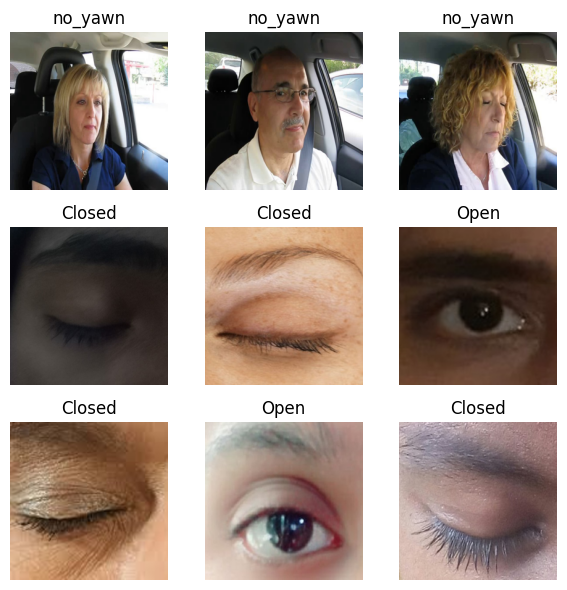

In [10]:
plt.figure(figsize=(6,6))
for i, (img, label) in enumerate(train_ds.unbatch().take(9)):
    plt.subplot(3,3,i+1)
    plt.imshow(img.numpy())
    plt.title(CLASSES[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
base_model = ConvNeXtLarge(
    include_top=False,
    weights="imagenet",
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    pooling="avg"
)

base_model.trainable = False

inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

x = base_model(inputs, training=False)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_large (Functional)     │ (None, 1536)           │   196,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 197,019,332 (751.57 MB)

 Trainable params: 788,996 (3.01 MB)

 Non-trainable params: 196,230,336 (748.56 MB)

In [12]:
model.compile(
    optimizer='adam',
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=5
)

Epoch 1/5
 1/78 ━━━━━━━━━━━━━━━━━━━━ 8:39:41 405s/step - accuracy: 0.3750 - loss: 1.4286

In [ ]:
plt.figure(figsize=(7,3))
plt.plot(history.history['loss'], 'p--', label='Perda treino')
plt.plot(history.history['val_loss'], 'm', label ='Perda validade')
plt.ylabel('Erro')
plt.xlabel('Épocas')
plt.grid(True)